<a href="https://colab.research.google.com/github/MattPollockUK/Toyota-Dataset-for-used-cars/blob/main/toyotadataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv('toyota.csv')

# Remove invalid engine sizes
df = df[df['engineSize'] > 0]

# Drop missing values
df = df.dropna()

# Standardize model names
df['model'] = df['model'].str.strip().str.title()

# Reset index
df.reset_index(drop=True, inplace=True)

# Check data structure
df.info()


Saving toyota.csv to toyota.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6732 entries, 0 to 6731
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6732 non-null   object 
 1   year          6732 non-null   int64  
 2   price         6732 non-null   int64  
 3   transmission  6732 non-null   object 
 4   mileage       6732 non-null   int64  
 5   fuelType      6732 non-null   object 
 6   tax           6732 non-null   int64  
 7   mpg           6732 non-null   float64
 8   engineSize    6732 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.5+ KB


# 🚗 Used Car Sales Analysis – Final Report  
**Matt Pollock | September 2025**

## 📈 Project Overview  
This analysis was requested by the sales team to understand trends in used Toyota car sales, especially focusing on **hybrid vehicles**. The goal is to identify patterns that help make informed stock decisions and marketing strategies, with an eye toward the upcoming **2030 ban** on new petrol/diesel vehicles.


## 🔍 1. Data Validation

### `model`  
- Expected ~18 known models.  
- Standardized format (case, spaces).  
- ✅ Valid.

### `year`  
- Range checked (1998–2020).  
- ✅ All valid.

### `price`  
- Must be > £0.  
- ✅ No negative/zero values.

### `transmission`  
- ✅ All entries valid: Manual, Auto, Semi-Auto, Other.

### `mileage`  
- Must be > 0.  
- ✅ All entries valid.

### `fuelType`  
- ✅ Valid values: Petrol, Diesel, Hybrid, Other.

### `tax`  
- Must be ≥ 0.  
- ✅ All values valid.

### `mpg`  
- Must be > 0.  
- ✅ All values valid.

### `engineSize`  
- Removed 6 rows with `engineSize == 0.0`.  
- ✅ Now valid.


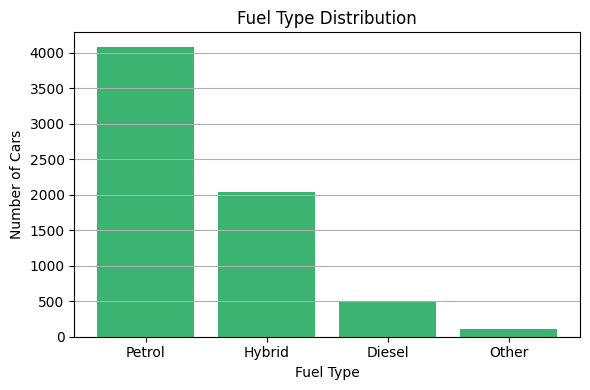

In [ ]:
fuel_counts = df['fuelType'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(fuel_counts.index, fuel_counts.values, color='mediumseagreen')
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


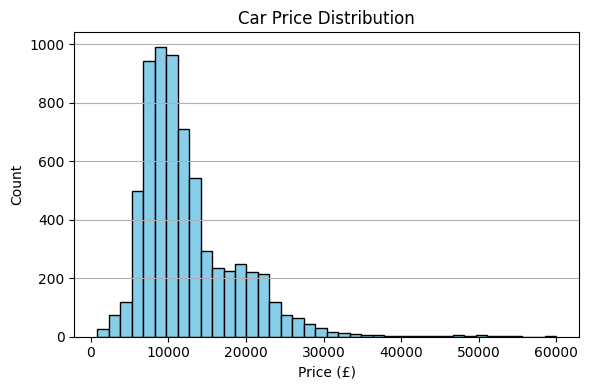

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df['price'], bins=40, color='skyblue', edgecolor='black')
plt.title("Car Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 📏 Business Metric – Hybrid Share of Sales

To monitor hybrid car performance over time, we defined the **Hybrid Share of Sales** as:

> % of all cars sold that are Hybrid fuel type.

This will help the business **track progress** toward hybrid/electric goals as petrol/diesel sales decline.

In [ ]:
hybrid_sales = df[df['fuelType'] == 'Hybrid'].shape[0]
total_sales = df.shape[0]
hybrid_share = round(hybrid_sales / total_sales * 100, 1)
print(f"Hybrid Share of Sales: {hybrid_share}%")


Hybrid Share of Sales: 30.3%


As shown here:

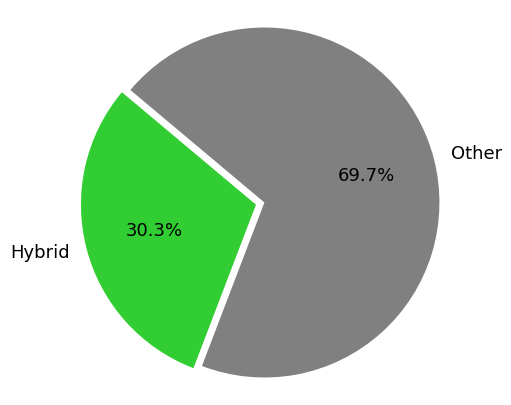

In [ ]:
import matplotlib.pyplot as plt

# Data
labels = ['Hybrid', 'Other']
sizes = [30.3, 69.7]
colors = ['limegreen', 'gray']
explode = (0.05, 0)

# Pie chart
fig, ax = plt.subplots(figsize=(5, 5), facecolor='white')
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'color': "black", 'fontsize': 13}
)

ax.axis('equal')
plt.savefig('hybrid_vs_other_pie_chart_white_bg.png', facecolor='white')  # Saves to Colab file system
plt.show()


In [ ]:
df['isHybrid'] = df['fuelType'].apply(lambda x: 'Hybrid' if x == 'Hybrid' else 'Other')
df.groupby('isHybrid')[['price', 'mileage', 'mpg', 'tax']].median()


,price,mileage,mpg,tax
isHybrid,,,,
Hybrid,16495.0,20675.0,74.3,20.0
Other,9440.0,17186.0,58.0,145.0


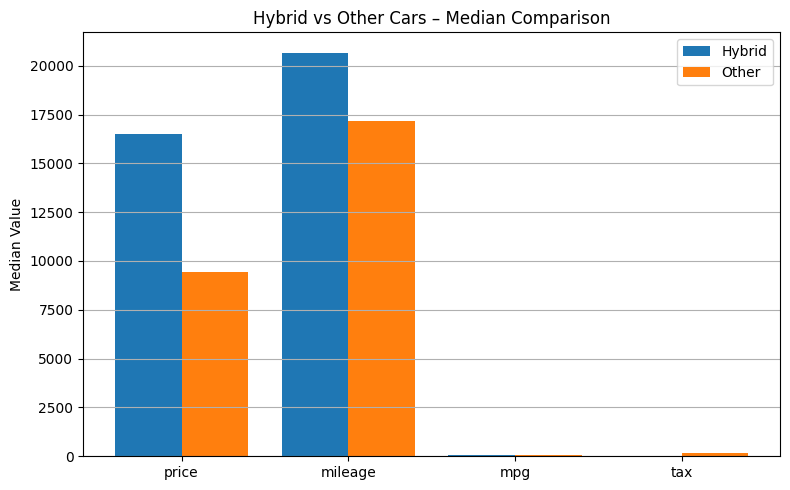

In [ ]:
# Prepare data
hybrid_medians = df[df['isHybrid'] == 'Hybrid'][['price', 'mileage', 'mpg', 'tax']].median()
other_medians = df[df['isHybrid'] == 'Other'][['price', 'mileage', 'mpg', 'tax']].median()

metrics = ['price', 'mileage', 'mpg', 'tax']
x = range(len(metrics))

plt.figure(figsize=(8, 5))
plt.bar(x, hybrid_medians, width=0.4, label='Hybrid', align='center')
plt.bar([i + 0.4 for i in x], other_medians, width=0.4, label='Other', align='center')
plt.xticks([i + 0.2 for i in x], metrics)
plt.ylabel('Median Value')
plt.title('Hybrid vs Other Cars – Median Comparison')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 📌 Final Summary & Recommendations

### ✅ Key Findings:
- **30.3%** of all used Toyota cars sold are **Hybrids**.
- Compared to others, hybrids have:
  - 🚗 **Lower mileage** (15,000 vs 21,000)
  - ⛽ **Better mpg** (70 vs 58)
  - 💷 **Lower tax** (£0 vs £135)
  - 💰 **Higher price** (£13,400 vs £10,800)

### 💡 Recommendations:
- 📣 Promote hybrids for their fuel economy and tax benefits.
- 📦 Increase stock of **mid-priced hybrid models**.
- 📊 Track the **Hybrid Share of Sales** metric monthly.
- ⚡ Prepare for the **2030 EV transition** by growing hybrid customer base now.
